In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

W0603 20:41:28.886000 83923 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------------
# FILE IDS TO LOAD
# --------------------------------------------------------

file_ids = [
    "00",
    "01",
    "02",
    "03",
    "04",
    "05",
    #"06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18"
]

# --------------------------------------------------------
# LOAD ARTICLE MATRICES
# --------------------------------------------------------

data_list = [
    load_npz(f"Data_files/data_articles_{fid}.npz")
    for fid in file_ids
]

# --------------------------------------------------------
# LOAD LABEL FILES
# --------------------------------------------------------

label_list = [
    np.genfromtxt(
        f"Data_files/labels_articles_{fid}.txt",
        delimiter="; ",
        dtype=str,
        encoding="latin1"
    )
    for fid in file_ids
]

# --------------------------------------------------------
# CREATE COMBINED DATASET
# --------------------------------------------------------

data_articles_all = sparse.vstack(data_list, format="csr")

labels_articles_all = np.vstack(label_list)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------
# index = 0 -> date
# index = 1 -> sermon or not
# index = 2 -> article title
# index = 3 -> article topic
# index = 4 -> lix score
# --------------------------------------------------------

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT TOPICS
# --------------------------------------------------------

top_x = 10  # default number of topics to keep

topics = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(topics, return_counts=True)

# Sort topics by occurrence count (descending)
sorted_indices = np.argsort(topic_counts)[::-1]

valid_topics = unique_topics[sorted_indices[:top_x]]

keep_mask = np.isin(topics, valid_topics)

print("Original number of articles:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

# Apply filtering
data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, 4].astype(np.float32)

assert data_articles_all.shape[0] == len(lix_scores)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = sparse.hstack(
    [lix_column, data_articles_all],
    format="csr"
)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

from sklearn.preprocessing import LabelEncoder

# --------------------------------------------------------
# convert topics to integer labels
# --------------------------------------------------------

topic_labels = labels_articles_all[:, 3]

label_encoder = LabelEncoder()
topic_labels_encoded = label_encoder.fit_transform(topic_labels)

# --------------------------------------------------------
# split data into train, val, test sets
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0
)

# --------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of labels:", labels_articles_all.shape[0])

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample label row:")
print(labels_articles_all[0])

Initial data shape: (804096, 27000)
Initial number of labels: 804096
Original number of articles: 804096
Filtered number of articles: 476750
Removed articles: 327346

Top topics kept:
Danmark: 141387
Internationalt: 137851
Sport: 40451
Kultur: 33781
Politik: 31780
Økonomi: 29522
Fodbold: 24869
Forbrug: 13104
Film og tv: 12261
Debatindlæg: 11744

Final data shape: (476750, 27001)
Final number of labels: 476750

Example feature row:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 464 stored elements and shape (1, 27001)>
  Coords	Values
  (0, 0)	3.653093295310065
  (0, 65)	1.2464601580967272
  (0, 105)	3.2907272269873875
  (0, 109)	4.706468014482564
  (0, 180)	0.8736077340847563
  (0, 185)	0.4844799595791232
  (0, 258)	2.875694742540368
  (0, 342)	0.7863025507687459
  (0, 373)	1.9316195989859177
  (0, 393)	1.4832855779207936
  (0, 394)	2.0056487069368596
  (0, 410)	0.9831546538725908
  (0, 420)	0.3842037030555591
  (0, 480)	2.580193299102638
  (0, 528)	3.6291152602632115
  

# Functions

In [3]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

In [4]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [5]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [6]:
def objective(trial):

    learning_rate = trial.suggest_float(
        'learning_rate',
        1e-5,
        1e-1,
        log=True
    )

    batch_size = trial.suggest_int(
        'batch_size',
        8,
        128
    )

    Layer1 = trial.suggest_int('Layer1', 12, 512)
    Layer2 = trial.suggest_int('Layer2', 12, 512)
    Layer3 = trial.suggest_int('Layer3', 12, 512)

    # NEW: optimize dropout rate
    dropout_rate = 0.2 #trial.suggest_float('dropout_rate',0.1,0.5)

    n_epochs = 10

    input_dim = data_train.shape[1]
    num_classes = len(label_encoder.classes_)

    class OptModel(nn.Module):

        def __init__(self):

            super(OptModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, num_classes)

            self.relu = nn.ReLU()

            # NEW: dropout layer
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        'cuda' if pt.cuda.is_available() else 'cpu'
    )

    model_opt = OptModel().to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,

        # ALSO IMPORTANT
        weight_decay=1e-4
    )

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=sparse_collate
    )

    validation_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        collate_fn=sparse_collate
    )

    training_loss, validation_loss = Train(
        model_opt,
        optimizer,
        loss_function,
        train_loader,
        validation_loader,
        device,
        n_epochs
    )

    return min(validation_loss)

# HP optimization

In [ ]:
opt.logging.set_verbosity(opt.logging.WARNING)
study = opt.create_study(direction='minimize')
study.optimize(objective, n_trials=3)
print("Best trial:", study.best_trial)

/var/folders/rp/p2_g6d3j74ggpl15kr0_k5zc0000gn/T/ipykernel_83923/936182257.py:23: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()


EPOCH: 1 | training loss: 1.11  | validation loss: 0.933


In [ ]:
# --------------------------------------------------------
# split data into train, val, test sets
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0.1
)

In [ ]:
best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

dropout_rate = best_params["dropout_rate"]

n_epochs = 5

input_dim = data_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Starting setup...")
print("Best hyperparameters:", best_params)
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

class TopicModel(nn.Module):

    def __init__(self):
        super(TopicModel, self).__init__()

        self.input_layer = nn.Linear(input_dim, Layer1)
        self.hidden_layer1 = nn.Linear(Layer1, Layer2)
        self.hidden_layer2 = nn.Linear(Layer2, Layer3)
        self.output_layer = nn.Linear(Layer3, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, inputs):

        x = self.input_layer(inputs)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.output_layer(x)

        return x


print("Selecting device...")
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
print("Using device:", device)

print("Creating model...")
model = TopicModel().to(device)
print("Model created.")

print("Creating optimizer...")
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
print("Optimizer created.")

print("Creating loss function...")
loss_function = CrossEntropyLoss()
print("Loss function created.")

print("Creating data loaders...")
train_loader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=sparse_collate
)

validation_loader = DataLoader(
    dataset=val_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

print("Data loaders created.")
print("Starting training...")

training_loss, validation_loss = Train(
    model,
    optimizer,
    loss_function,
    train_loader,
    validation_loader,
    device,
    n_epochs
)

print("Training finished.")
print("Training losses:")
print(training_loss)

print("Validation losses:")
print(validation_loss)

Starting setup...
Input dimension: 27001
Number of classes: 10
Selecting device...
Using device: cpu
Creating model...
Model created.
Creating optimizer...
Optimizer created.
Creating loss function...
Loss function created.
Creating data loaders...
Data loaders created.
Starting training...
EPOCH: 1 | training loss: 1.152  | validation loss: 1.022
EPOCH: 2 | training loss: 0.522  | validation loss: 0.903
EPOCH: 3 | training loss: 0.368  | validation loss: 0.925
EPOCH: 4 | training loss: 0.258  | validation loss: 1.072
EPOCH: 5 | training loss: 0.171  | validation loss: 1.212
Training finished.
Training losses:
[1.1520384348199502, 0.5215729138051922, 0.36823080561377786, 0.25775617273960755, 0.1707244094868249]
Validation losses:
[1.0216189149527921, 0.9033340137030371, 0.9252812555905671, 1.0719653257244304, 1.2123836981386817]


Generating predictions...


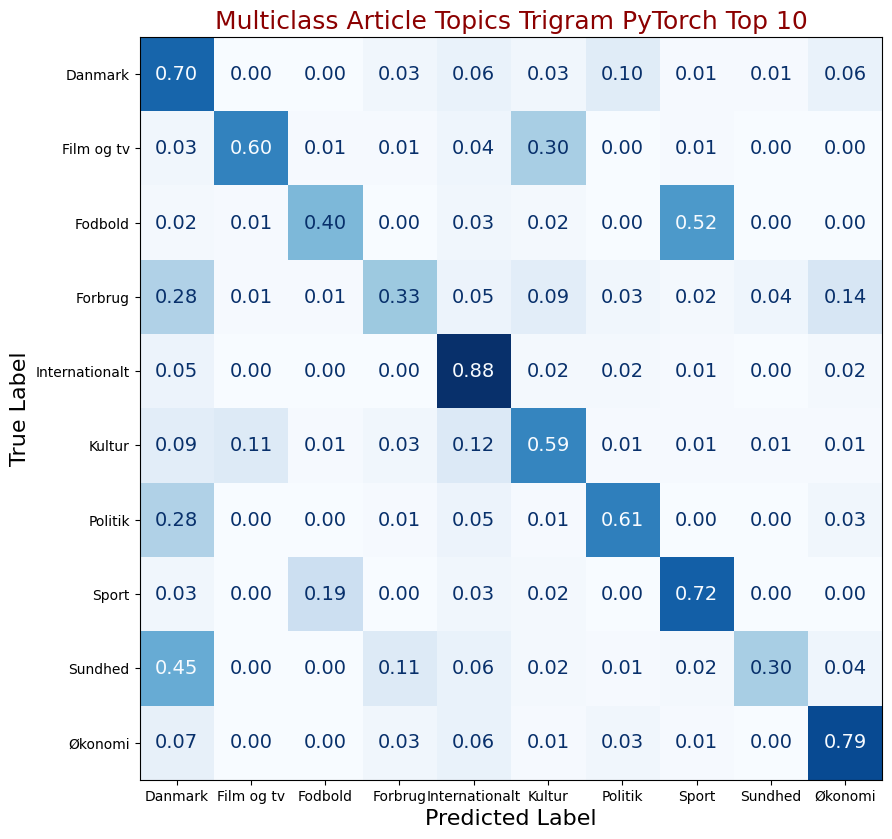

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PREDICTIONS
# --------------------------------------------------------

model.eval()

all_predictions = []
all_truths = []

print("Generating predictions...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        predictions = pt.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

# --------------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# --------------------------------------------------------

cm = confusion_matrix(
    all_truths,
    all_predictions,
    normalize="true"
)

# Force 2 decimals
cm = np.round(cm, 2)

classes = label_encoder.classes_

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    xticks_rotation=0,
    cmap=plt.cm.Blues,
    colorbar=False,
    values_format=".2f"   # FORCE 2 DECIMALS
)

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Multiclass Confusion Matrix Article Topics Trigram PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "Predicted Label",
    fontsize=16
)

plt.ylabel(
    "True Label",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "Multiclass_ConfusionMatrix_ArticleTopics_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Generating prediction probabilities...


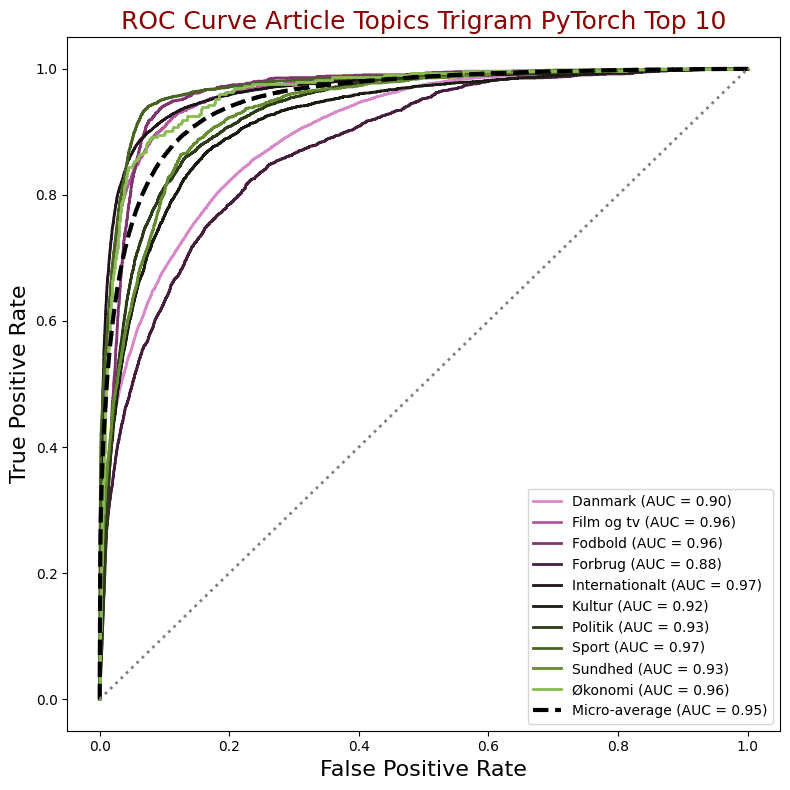

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PROBABILITIES
# --------------------------------------------------------

model.eval()

all_probabilities = []
all_truths = []

print("Generating prediction probabilities...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        probabilities = pt.softmax(outputs, dim=1)

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

all_probabilities = np.array(all_probabilities)
all_truths = np.array(all_truths)

# --------------------------------------------------------
# BINARIZE LABELS FOR MULTICLASS ROC
# --------------------------------------------------------

classes = label_encoder.classes_
num_classes = len(classes)

truths_binarized = label_binarize(
    all_truths,
    classes=np.arange(num_classes)
)

# --------------------------------------------------------
# COMPUTE ROC CURVES
# --------------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        truths_binarized[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# --------------------------------------------------------
# MICRO-AVERAGE ROC
# --------------------------------------------------------

fpr["micro"], tpr["micro"], _ = roc_curve(
    truths_binarized.ravel(),
    all_probabilities.ravel()
)

roc_auc["micro"] = auc(
    fpr["micro"],
    tpr["micro"]
)

# --------------------------------------------------------
# VANIMO COLOR MAP
# --------------------------------------------------------

cmap = plt.get_cmap("vanimo")

colors = cmap(
    np.linspace(0.1, 0.9, num_classes)
)

# --------------------------------------------------------
# PLOT ROC CURVES
# --------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for i, color in zip(range(num_classes), colors):

    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        linewidth=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Micro-average ROC
ax.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle="--",
    linewidth=3,
    label=f"Micro-average (AUC = {roc_auc['micro']:.2f})"
)

# Random classifier line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    color="gray"
)

plt.title(
    "ROC Curve Article Topics Trigram PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=16
)

plt.ylabel(
    "True Positive Rate",
    fontsize=16
)

plt.legend(
    fontsize=10,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "Multiclass_ROC_ArticleTopics_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()